In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

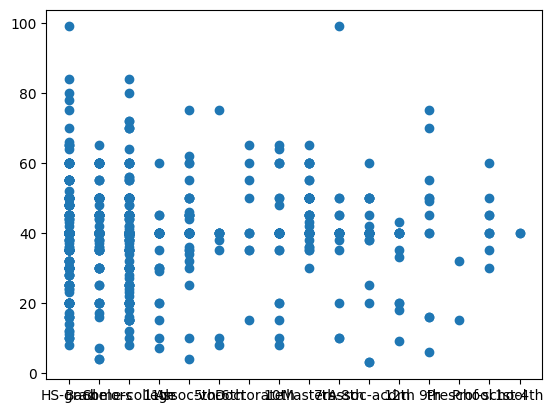

In [7]:
df = pd.read_csv('adult.csv')
df.dropna(inplace=True)
df_sample = df.sample(n=1000, random_state=42)
plt.scatter(df_sample['education'], df_sample['hours-per-week'])
plt.show()

Iteration 0: Loss = 1693.7323981016852
Iteration 100: Loss = 223.10384365215194
Iteration 200: Loss = 204.1454486035625
Iteration 300: Loss = 203.7434093870126
Iteration 400: Loss = 203.5789332633074
Iteration 500: Loss = 203.41785923623354
Iteration 600: Loss = 203.25719330229649
Iteration 700: Loss = 203.09689635438346
Iteration 800: Loss = 202.93696705829407
Iteration 900: Loss = 202.77740456456715


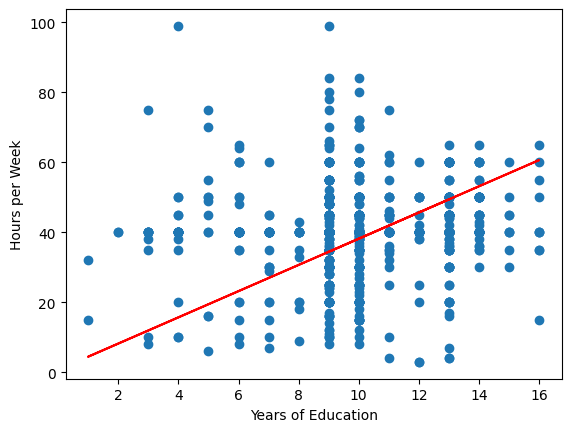

In [11]:


def loss(a, b, pts):
    total_loss = 0
    for i in range(len(pts)):
        x = pts.iloc[i]['educational-num']
        y = pts.iloc[i]['hours-per-week']
        total_loss += (y - (a*x + b))**2
    return total_loss / len(pts)

def step_gradient(a_current, b_current, pts, learning_rate):
    a_gradient = 0
    b_gradient = 0
    N = float(len(pts))
    for i in range(len(pts)):
        x = pts.iloc[i]['educational-num']
        y = pts.iloc[i]['hours-per-week']
        
        a_gradient += -(2/N) * x * (y - (a_current*x + b_current))
        b_gradient += -(2/N) * (y - (a_current*x + b_current))
        
    new_a = a_current - (learning_rate * a_gradient)
    new_b = b_current - (learning_rate * b_gradient)
    return new_a, new_b

a = 0
b = 0
learning_rate = 0.0001
num_iterations = 1000

for i in range(num_iterations):
    a, b = step_gradient(a, b, df_sample, learning_rate)
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss(a, b, df_sample)}")

plt.scatter(df_sample['educational-num'], df_sample['hours-per-week'])
plt.plot(df_sample['educational-num'], a*df_sample['educational-num'] + b, color='red')
plt.xlabel("Years of Education")
plt.ylabel("Hours per Week")
plt.show()

If we did not have theta0, our equation would just be h(x) = theta(x). Mathematically, if x1 = 0, then the prediction must be 0. This means our regression line would be forced to pass exactly through the origin (0,0).For almost all real-world datasets, the true relationship doesn't cleanly pass through the origin. If you try to fit a line through the origin for data that is shifted away from it, your model will perform terribly. We absolutely need theta0 to allow our regression plane to shift up or down to find the best fit.


Now, our feature vector x becomes [1, x1, x2,..., x_n].Let's look at what happens when we multiply our parameters theta by our new features x:h(x) = (theta0 * x0) + (theta1 * x1) + .... + (theta n * xn)Because x0 is always exactly 1, the first term (theta0 * 1) just becomes theta_0. We have successfully absorbed the intercept term into the feature matrix!

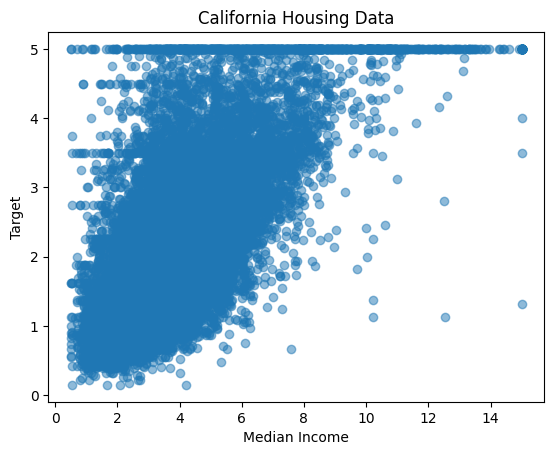

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


california_data = fetch_california_housing()

plt.scatter(california_data.data[:, 0], california_data.target, alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("Target")
plt.title("California Housing Data")
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score


class LinearRegression_closed:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = 0.0
    def fit(self,X,y):
        X = np.array(X)
        y = np.array(y)
        Xb = np.c_[np.ones((X.shape[0], 1)), X]
        theta = np.linalg.inv(Xb.T.dot(Xb)).dot(Xb.T).dot(y)
        self.coef_ = theta[1:]
        self.intercept_ = theta[0]
    def predict(self,X):
        X = np.array(X)
        return self.intercept_ + X.dot(self.coef_)
reg = LinearRegression_closed()
X,y = fetch_california_housing(return_X_y=True)
reg.fit(X,y)
y_pred = reg.predict(X)
print(f"R^2 Score by the class: {r2_score(y, y_pred)}")
reg_sklearn = LinearRegression()
reg_sklearn.fit(X,y)
y_pred_sklearn = reg_sklearn.predict(X)
print(f"R^2 Score by sklearn: {r2_score(y, y_pred_sklearn)}")

R^2 Score by the class: 0.606232685199805
R^2 Score by sklearn: 0.606232685199805


Ridge regression is a awesome way to solve overfitting..if your data is over fit, like following 7th degree equations and its a balanced fit in 5th degree equation, u need to reduce the values of the 6th and 7th degree coefficients. That is why u add a theta^2 with a tuning factor lambda (alpha in code) to punish the higher values in mse(in mean square error, ur goal is to reduce the derivative).The following is L2 regularization

In [9]:
from sklearn.linear_model import Ridge
class RidgeRegression_closed:
    def __init__(self, alpha=2.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = 0.0
    def fit(self,X,y):
        X = np.array(X)
        y = np.array(y)
        Xb = np.c_[np.ones((X.shape[0], 1)), X]
        I = np.eye(Xb.shape[1])
        I[0, 0] = 0
        theta = np.linalg.inv(Xb.T.dot(Xb) + self.alpha * I).dot(Xb.T).dot(y)
        self.coef_ = theta[1:]
        self.intercept_ = theta[0]
    def predict(self,X):
        X = np.array(X)
        return self.intercept_ + X.dot(self.coef_)
X,y = fetch_california_housing(return_X_y=True)
ridge_reg = RidgeRegression_closed(alpha=2.0)
ridge_reg.fit(X,y)
print(f"R^2 Score by Ridge Regression class: {r2_score(y, ridge_reg.predict(X))}")
print(f"R^2 Score by sklearn's Ridge: {r2_score(y, Ridge(alpha=2.0).fit(X, y).predict(X))}")

R^2 Score by Ridge Regression class: 0.6062325794705159
R^2 Score by sklearn's Ridge: 0.6062325794705161
